# Two-Phase Bayesian Optimization — NYX & Miranda (combined 2×2)

Runs the joint **LR × slice-direction** two-phase BO pipeline on **both** datasets
and renders one **2×2** figure:

|            | **Phase 1** (proxy BO) | **Phase 2** (full-res validation) |
|------------|------------------------|-----------------------------------|
| **NYX**    | top-left               | top-right                         |
| **Miranda**| bottom-left            | bottom-right                      |

Budgets: **NYX = 60 s**, **Miranda = 120 s**.  For each: **Phase 1 = 10 %** of the
budget, **Phase 2 = the remaining 90 %**, **10 trials** each.

The shared `run_two_phase(...)` function is the same logic as the single-dataset
notebooks, refactored to return everything the combined plot needs.

In [1]:
import random, sys, os, copy, time
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sys.path.append("/home/sam/Halo_Finder/Final_design/base_script")

from config_io import load_multifield_from_disk
# Force-reload edited modules so re-running picks up bg_stage.py changes WITHOUT
# restarting the kernel (Jupyter caches modules in sys.modules).
import importlib
import bg_stage
importlib.reload(bg_stage)

from experiment import build_bg_only_cfg
from bg_stage import run_bg_inference, train_bg_only, unwrap_bg_model
from bg_shard import pick_bg_h_under_budget

pysz_dir = "/home/sam/Data_Compression/SZ3/tools/pysz"
if pysz_dir not in sys.path:
    sys.path.append(pysz_dir)
from pysz import SZ

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | GPUs: {torch.cuda.device_count()}")

Device: cuda:0 | GPUs: 1


/home/sam/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Slice-direction permutations ──────────────────────────────────────────────
# Data layout: (Z, Y, X). Permute so the target slice axis becomes axis-0 (depth).
DIRECTIONS = ["Z", "Y", "X"]
_FWD = {"Z": (0, 1, 2), "Y": (1, 0, 2), "X": (2, 0, 1)}
_INV = {"Z": (0, 1, 2), "Y": (1, 0, 2), "X": (1, 2, 0)}
_DIR_AXIS = {"Z": 0, "Y": 1, "X": 2}


def permute_fields(fields, direction):
    axes = _FWD[direction]
    if axes == (0, 1, 2):
        return fields
    return [np.ascontiguousarray(np.transpose(f, axes)) for f in fields]


def unpermute_field(field, direction):
    axes = _INV[direction]
    if axes == (0, 1, 2):
        return field
    return np.ascontiguousarray(np.transpose(field, axes))


def build_cfg(Xs_in, Xps_in, max_train_time, bg_h, steps_per_epoch,
              lr=1e-4, epochs=200, log_prefix="", patch_size=None):
    if patch_size is None:
        patch_size = Xs_in[0].shape[2]
    cfg = build_bg_only_cfg(
        X_target=Xs_in[0], Xps=Xps_in,
        max_train_time=max_train_time, epochs=epochs,
        steps_per_epoch=steps_per_epoch, bg_h=bg_h,
        bg_batch=1, bg_patch_size=patch_size, lr=lr,
    )
    cfg.bg_sample_mode   = "sequential"
    cfg.bg_log_prefix    = log_prefix
    cfg.bg_arch          = "spatial"
    cfg.amp              = False
    cfg.amp_dtype        = "bf16"
    cfg.bg_ddp           = False
    cfg.bg_data_parallel = False
    return cfg


def psnr_from_arrays(target, recon):
    data_range = float(target.max() - target.min())
    if data_range <= 0:
        data_range = 1.0
    mse = float(np.mean((target - recon) ** 2))
    return 100.0 if mse <= 0 else 20.0 * np.log10(data_range) - 10.0 * np.log10(mse)


# Shared plot styling
dir_colors  = {"Z": "#1f77b4", "Y": "#ff7f0e", "X": "#2ca02c"}
dir_markers = {"Z": "o",       "Y": "s",        "X": "^"}

print("Helpers ready")

Helpers ready


In [3]:
# ── Paths & SZ engine ─────────────────────────────────────────────────────────
halo_finder_root = Path("/home/sam/Halo_Finder")
sz_lib_path = "/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"
pysz_script = "/home/sam/Halo_Finder/halo_finder_v1/ROI_Compression/pysz.py"
sz_engine   = SZ(sz_lib_path)
print("SZ engine loaded")


def _rel_suffix(rel_err):
    return f"{float(rel_err):.0e}".replace("+", "")


# ── NYX: multifield 512^3 (baryon_density target + 5 aux fields) ──────────────
NYX_BASE = (halo_finder_root /
            "halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin").as_posix() + "/"
NYX_SHAPE = (512, 512, 512)
NYX_FIELD_FILES = [
    "baryon_density.f32", "temperature.f32", "dark_matter_density.f32",
    "velocity_z.f32", "velocity_x.f32", "velocity_y.f32",
]
NYX_TARGET_STEM = "baryon_density"


def load_nyx(target_stem=NYX_TARGET_STEM, rel_err=1e-5):
    fname     = f"{target_stem}.f32"
    gt_path   = NYX_BASE + fname
    aux_paths = [NYX_BASE + f for f in NYX_FIELD_FILES if f != fname]
    sz_bin    = NYX_BASE + Path(fname).stem + "_rel" + _rel_suffix(rel_err) + ".sz"

    if not Path(sz_bin).is_file():
        vol = np.fromfile(gt_path, dtype=np.float32).reshape(NYX_SHAPE)
        Path(sz_bin).write_bytes(sz_engine.compress(vol, 1, 0, float(rel_err), 0)[0])
        print(f"Created SZ binary: {sz_bin}")

    Xs_raw, _ = load_multifield_from_disk(
        gt_path=gt_path, aux_paths=aux_paths, sz_bin_path=sz_bin,
        data_shape=NYX_SHAPE, pysz_path=pysz_script, sz_lib_path=sz_lib_path,
    )
    Xs         = [np.asarray(f, np.float32) for f in Xs_raw]
    aux_fields = [np.asarray(f, np.float32) for f in Xs_raw[1:]]
    b, cr      = sz_engine.compress(Xs[0], 1, 0, float(rel_err), 0)
    x_lq       = sz_engine.decompress(b, Xs[0].shape, np.float32)
    Xps_list   = [np.asarray(x_lq, np.float32)] + aux_fields
    return Xs, Xps_list, float(cr), int(len(b))


# ── Miranda: single-field 1024^3 raw ──────────────────────────────────────────
MIRANDA_RAW   = (halo_finder_root /
                 "halo_finder_v1/miranda_1024x1024x1024_float32.raw").as_posix()
MIRANDA_SHAPE = (1024, 1024, 1024)


def load_miranda(rel_err=1e-2):
    vol      = np.fromfile(MIRANDA_RAW, dtype=np.float32).reshape(MIRANDA_SHAPE)
    Xs       = [vol]
    b, cr    = sz_engine.compress(vol, 1, 0, float(rel_err), 0)
    x_lq     = sz_engine.decompress(b, vol.shape, np.float32).astype(np.float32)
    Xps_list = [x_lq]
    return Xs, Xps_list, float(cr), int(len(b))


print("Loaders ready")

SZ engine loaded
Loaders ready


In [4]:
def run_two_phase(Xs, Xps_list, *, dataset_name, total_time, test_rel_err,
                  tune_depth, freq_warmup, sz_cr=None,
                  s_spatial=2, n_trials=10, phase1_frac=0.10,
                  param_budget=30000):
    # Run Phase-1 proxy BO + Phase-2 full-res validation sweep.
    # Returns a dict with everything the combined 2x2 plot needs.
    data_shape    = Xs[0].shape
    PHASE1_TIME   = total_time * phase1_frac
    PER_TRIAL_CAP = PHASE1_TIME / n_trials
    TUNE_EPOCHS   = 999

    print(f"\n{'='*64}\n[{dataset_name}] total={total_time:.0f}s  "
          f"Phase1<= {PHASE1_TIME:.0f}s  rel={test_rel_err:.0e}\n{'='*64}")

    # ── Phase-1 proxy: take tune_depth planes FIRST, then transpose tiny result ──
    def make_proxy(fields, direction, n_keep=tune_depth, S=s_spatial):
        axis = _DIR_AXIS[direction]
        n    = fields[0].shape[axis]
        idx  = np.unique(np.linspace(0, n - 1, n_keep).round().astype(int))
        out  = []
        for f in fields:
            sub = np.take(f, idx, axis=axis)
            sub = np.transpose(sub, _FWD[direction])
            out.append(np.ascontiguousarray(sub[:, ::S, ::S]))
        return out

    t0 = time.time()
    proxy_cache = {d: (make_proxy(Xs, d), make_proxy(Xps_list, d)) for d in DIRECTIONS}
    proxy_shape = proxy_cache["Z"][0][0].shape
    print(f"Proxy cache built in {time.time()-t0:.2f}s | shape: {proxy_shape}")

    try:
        bg_h_tune, _ = pick_bg_h_under_budget(
            param_budget, shape=proxy_shape,
            n_fields=len(proxy_cache["Z"][1]), bg_arch="spatial")
        bg_h_tune = int(bg_h_tune)
    except Exception:
        bg_h_tune = 10

    print(f"Phase 1 proxy: {proxy_shape[0]} slices x {proxy_shape[1]}x{proxy_shape[2]} | "
          f"bg_h={bg_h_tune} | {n_trials} trials x {PER_TRIAL_CAP:.2f}s/trial")

    all_tune_histories = {}
    phase1_start = 0.0   # bound just before study.optimize; objective reads it

    def objective(trial):
        lr        = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        direction = trial.suggest_categorical("direction", DIRECTIONS)
        Xs_sub, Xps_sub = proxy_cache[direction]
        n_depth  = Xs_sub[0].shape[0]
        patch_sz = Xs_sub[0].shape[2]

        t_trial = time.time()
        tune_cfg = build_cfg(
            Xs_sub, Xps_sub, max_train_time=PER_TRIAL_CAP, bg_h=bg_h_tune,
            steps_per_epoch=n_depth, lr=lr, epochs=TUNE_EPOCHS,
            log_prefix=f"BO-{direction}-{lr:.1e}", patch_size=patch_sz)
        tune_cfg.bg_freq_warmup_epochs = freq_warmup

        def evaluator(m, cfg=tune_cfg, Xs_d=Xs_sub, Xps_d=Xps_sub):
            m_core = unwrap_bg_model(m)
            xh     = run_bg_inference(m_core, Xs_d, Xps_d, cfg, test_rel_err)
            return psnr_from_arrays(Xs_d[0], xh), 0.0

        set_seed(42)
        _, hist = train_bg_only(Xs=Xs_sub, Xps=Xps_sub, device=device,
                                cfg=tune_cfg, evaluator=evaluator)
        psnr_vals  = [v[1] if isinstance(v, tuple) else v for v in hist.get("psnr", [])]
        final_psnr = psnr_vals[-1] if psnr_vals else -1.0
        all_tune_histories[(lr, direction)] = hist
        print(f"  Trial {trial.number:2d}: lr={lr:.2e}  dir={direction}  "
              f"PSNR={final_psnr:.2f} dB  [{time.time()-t_trial:.1f}s/trial  "
              f"{time.time()-phase1_start:.0f}s elapsed]")
        return final_psnr

    # GPU warm-up (not counted in budget)
    _wXs, _wXps = proxy_cache["Z"]
    _wcfg = build_cfg(_wXs, _wXps, max_train_time=0.5, bg_h=bg_h_tune,
                      steps_per_epoch=2, lr=1e-3, epochs=1,
                      log_prefix="warmup", patch_size=_wXs[0].shape[2])
    set_seed(42)
    train_bg_only(Xs=_wXs, Xps=_wXps, device=device, cfg=_wcfg,
                  evaluator=lambda m, cfg=_wcfg: (0.0, 0.0))
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    print("GPU warm-up done")

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=4))
    for d in DIRECTIONS:
        study.enqueue_trial({"lr": 1e-3, "direction": d})

    phase1_start   = time.time()
    # No `timeout=` here on purpose: we want ALL n_trials to run so the paper
    # plots show 10 trials per dataset. Per-trial wall-time is still bounded by
    # PER_TRIAL_CAP, so Phase 1 stays ~= PHASE1_TIME (may slightly overshoot).
    study.optimize(objective, n_trials=n_trials)
    phase1_elapsed = time.time() - phase1_start

    best_lr        = study.best_params["lr"]
    best_direction = study.best_params["direction"]
    n_done         = len(study.trials)
    PHASE2_TIME    = total_time - phase1_elapsed
    print(f"\n[{dataset_name}] Phase 1 done in {phase1_elapsed:.1f}s "
          f"({n_done} trials) | Phase 2 budget {PHASE2_TIME:.1f}s")
    print(f"  Best (proxy): lr={best_lr:.2e}  dir={best_direction}  "
          f"PSNR={study.best_value:.2f} dB")

    # ── Phase 2: re-run every (lr, dir) combo on the full volume ──────────────
    try:
        bg_h_p2, _ = pick_bg_h_under_budget(
            param_budget, shape=Xs[0].shape, n_fields=len(Xps_list), bg_arch="spatial")
        bg_h_p2 = int(bg_h_p2)
    except Exception:
        bg_h_p2 = 10

    full_histories = {}
    for direction_p2 in DIRECTIONS:
        lrs_this_dir = [lr for (lr, d) in all_tune_histories if d == direction_p2]
        if not lrs_this_dir:
            continue
        t0 = time.time()
        Xs_perm  = permute_fields(Xs, direction_p2)
        Xps_perm = permute_fields(Xps_list, direction_p2)
        n_depth  = Xs_perm[0].shape[0]
        patch_sz = Xs_perm[0].shape[2]
        print(f"\n# [{dataset_name}] dir {direction_p2}: {len(lrs_this_dir)} configs "
              f"(permute {time.time()-t0:.1f}s)")

        for lr_p2 in lrs_this_dir:
            p2_cfg = build_cfg(
                Xs_perm, Xps_perm, max_train_time=PHASE2_TIME, bg_h=bg_h_p2,
                steps_per_epoch=n_depth, lr=lr_p2, epochs=200,
                log_prefix=f"P2-{direction_p2}-{lr_p2:.1e}", patch_size=patch_sz)
            p2_cfg.bg_early_stop         = False
            p2_cfg.bg_es_metric          = "loss_patience"
            p2_cfg.bg_es_min_drop        = 0.02
            p2_cfg.bg_es_patience        = 2
            p2_cfg.bg_freq_warmup_epochs = freq_warmup

            def evaluator_p2(m, cfg=p2_cfg, Xs_p=Xs_perm, Xps_p=Xps_perm,
                             dir_=direction_p2):
                m_core  = unwrap_bg_model(m)
                xh_perm = run_bg_inference(m_core, Xs_p, Xps_p, cfg, test_rel_err)
                xh      = unpermute_field(xh_perm, dir_)
                return psnr_from_arrays(Xs[0], xh), 0.0

            set_seed(42)
            _, hist = train_bg_only(Xs=Xs_perm, Xps=Xps_perm, device=device,
                                    cfg=p2_cfg, evaluator=evaluator_p2)
            full_histories[(lr_p2, direction_p2)] = hist
        del Xs_perm, Xps_perm

    def _final(hist):
        ps = [v[1] if isinstance(v, tuple) else v for v in hist.get("psnr", [])]
        return ps[-1] if ps else None
    final_psnr   = {c: _final(h) for c, h in full_histories.items()}
    final_psnr   = {c: v for c, v in final_psnr.items() if v is not None}
    final_winner = max(final_psnr, key=final_psnr.get) if final_psnr else None

    bo_pick = (best_lr, best_direction)
    gap = (final_psnr[final_winner] - final_psnr.get(bo_pick, final_psnr[final_winner])
           if final_winner else float("nan"))
    print(f"\n[{dataset_name}] BO pick {bo_pick} -> "
          f"{final_psnr.get(bo_pick, float('nan')):.2f} dB | "
          f"true best {final_winner} -> {final_psnr.get(final_winner, float('nan')):.2f} dB "
          f"(gap {gap:.2f} dB)")

    return dict(
        dataset_name=dataset_name, total_time=total_time, test_rel_err=test_rel_err,
        tune_depth=tune_depth, s_spatial=s_spatial, data_shape=data_shape, sz_cr=sz_cr,
        study_trials=[(t.number, t.params["lr"], t.params["direction"], t.value)
                      for t in study.trials],
        all_tune_histories=all_tune_histories, full_histories=full_histories,
        best_lr=best_lr, best_direction=best_direction,
        final_winner=final_winner, final_psnr=final_psnr,
        phase1_elapsed=phase1_elapsed, phase2_time=PHASE2_TIME,
        per_trial_cap=PER_TRIAL_CAP, n_done=n_done,
    )

print("run_two_phase ready")

run_two_phase ready


In [18]:
# ── NYX: 60 s budget ──────────────────────────────────────────────────────────
NYX_REL = 1e-5
Xs, Xps_list, sz_cr, sz_bytes = load_nyx(rel_err=NYX_REL)
print(f"NYX loaded | shape {Xs[0].shape} | {len(Xs)} fields | "
      f"SZ3 rel={NYX_REL:.0e} CR={sz_cr:.2f}x")

result_nyx = run_two_phase(
    Xs, Xps_list, dataset_name="NYX", total_time=10.0, test_rel_err=NYX_REL,
    tune_depth=32, freq_warmup=1, sz_cr=sz_cr, param_budget=30000,
)

# Free the large NYX volumes before loading Miranda (1024^3 is heavy)
del Xs, Xps_list
import gc; gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("NYX done; volumes freed")

NYX loaded | shape (512, 512, 512) | 6 fields | SZ3 rel=1e-05 CR=439.58x

[NYX] total=10s  Phase1<= 1s  rel=1e-05
Proxy cache built in 0.61s | shape: (32, 256, 256)

[Model: spatial] Total Params: 859
 [Params] Main (BG) Network : 859 parameters

[Model: spatial] Total Params: 1,396
 [Params] Main (BG) Network : 1,396 parameters

[Model: spatial] Total Params: 2,059
 [Params] Main (BG) Network : 2,059 parameters

[Model: spatial] Total Params: 2,848
 [Params] Main (BG) Network : 2,848 parameters

[Model: spatial] Total Params: 3,763
 [Params] Main (BG) Network : 3,763 parameters

[Model: spatial] Total Params: 4,804
 [Params] Main (BG) Network : 4,804 parameters

[Model: spatial] Total Params: 5,971
 [Params] Main (BG) Network : 5,971 parameters

[Model: spatial] Total Params: 7,264
 [Params] Main (BG) Network : 7,264 parameters

[Model: spatial] Total Params: 8,683
 [Params] Main (BG) Network : 8,683 parameters

[Model: spatial] Total Params: 10,228
 [Params] Main (BG) Network : 10,22

/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


BO-Z-1.0e-03 Epoch   1 [BG] | train_wall=0.07s | Loss: 0.980175 | Freq: 3.060964 | Global: 79.78 dB | MaxErr: 0.0  [New Best!]
BO-Z-1.0e-03 [timing] first_epoch_pure_train≈0.075s (excludes this epoch's end-of-epoch eval)
BO-Z-1.0e-03 Epoch   2 [BG] | train_wall=0.03s | Loss: 3.978646 | Freq: 3.022646 | Global: 79.77 dB | MaxErr: 0.0

BO-Z-1.0e-03 --- Experiment [BG_only] finished ---
BO-Z-1.0e-03 --- Pure training time: 0.10 s ---
BO-Z-1.0e-03 [timing] epochs=2 | train_wall/epoch: mean=0.05s min=0.03s max=0.07s | sum=0.09s
BO-Z-1.0e-03 --- Best global PSNR: 79.78 dB ---
  Trial  0: lr=1.00e-03  dir=Z  PSNR=79.77 dB  [0.2s/trial  0s elapsed]

[Model: spatial] Total Params: 29,803
 [Params] Main (BG) Network : 29,803 parameters
BO-Y-1.0e-03 [Init] Epoch   0 | Global PSNR: 80.98 dB | MaxErr: 0.0
BO-Y-1.0e-03 [plan] pure_train_budget=0.10s | epochs_cap=999 | steps/epoch=32 | patch=256 | batch=1 | sample=sequential | data_parallel=False | amp=off
BO-Y-1.0e-03 [early-stop] DISABLED (cfg.bg_e

In [6]:
# ── Miranda: 120 s budget ─────────────────────────────────────────────────────
MIRANDA_REL = 1e-2
Xs, Xps_list, sz_cr, sz_bytes = load_miranda(rel_err=MIRANDA_REL)
print(f"Miranda loaded | shape {Xs[0].shape} | {len(Xs)} field(s) | "
      f"SZ3 rel={MIRANDA_REL:.0e} CR={sz_cr:.2f}x")

result_miranda = run_two_phase(
    Xs, Xps_list, dataset_name="Miranda", total_time=120.0, test_rel_err=MIRANDA_REL,
    tune_depth=64, freq_warmup=1, sz_cr=sz_cr, param_budget=240000,
)

del Xs, Xps_list
import gc; gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("Miranda done; volumes freed")

Miranda loaded | shape (1024, 1024, 1024) | 1 field(s) | SZ3 rel=1e-02 CR=199.71x

[Miranda] total=120s  Phase1<= 12s  rel=1e-02
Proxy cache built in 0.70s | shape: (64, 512, 512)

[Model: spatial] Total Params: 724
 [Params] Main (BG) Network : 724 parameters

[Model: spatial] Total Params: 1,216
 [Params] Main (BG) Network : 1,216 parameters

[Model: spatial] Total Params: 1,834
 [Params] Main (BG) Network : 1,834 parameters

[Model: spatial] Total Params: 2,578
 [Params] Main (BG) Network : 2,578 parameters

[Model: spatial] Total Params: 3,448
 [Params] Main (BG) Network : 3,448 parameters

[Model: spatial] Total Params: 4,444
 [Params] Main (BG) Network : 4,444 parameters

[Model: spatial] Total Params: 5,566
 [Params] Main (BG) Network : 5,566 parameters

[Model: spatial] Total Params: 6,814
 [Params] Main (BG) Network : 6,814 parameters

[Model: spatial] Total Params: 8,188
 [Params] Main (BG) Network : 8,188 parameters

[Model: spatial] Total Params: 9,688
 [Params] Main (BG) N

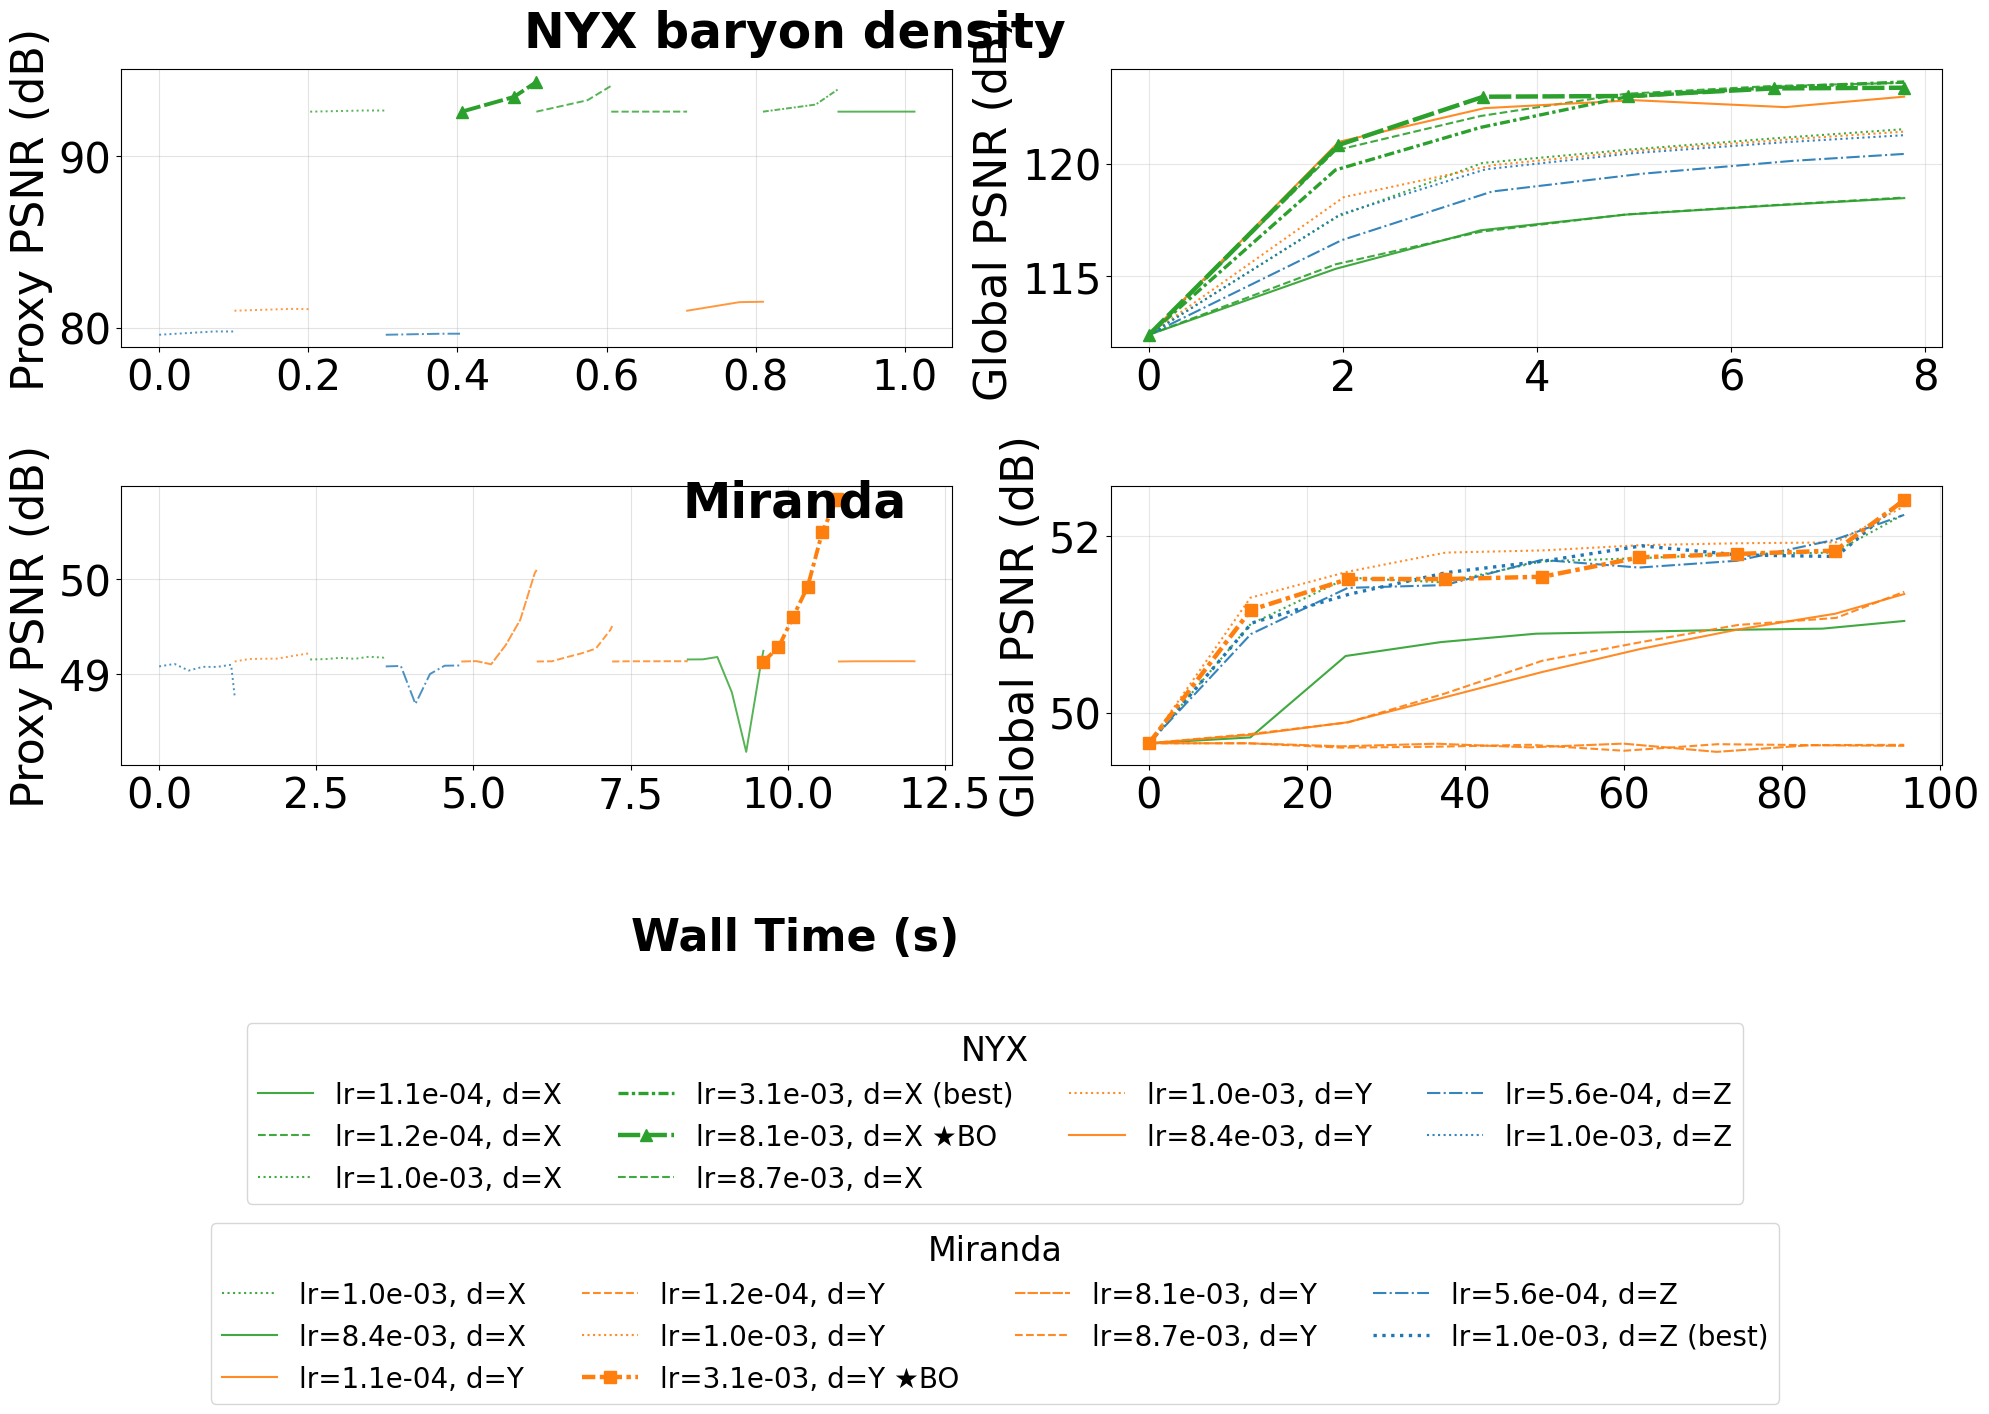

Saved: NYX_Miranda_2x2.pdf


In [26]:
# ── Combined 2x2 figure: rows = NYX / Miranda, cols = Phase 1 / Phase 2 ───────
_LS = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1))]

def _psnr_list(hist):
    return [v[1] if isinstance(v, tuple) else v for v in hist.get("psnr", [])]

def plot_phase1(ax, R, fontsize=40):
    trials  = sorted(R["study_trials"], key=lambda x: x[0])      # by trial number
    all_lrs = sorted({lr for (_, lr, _, _) in trials})
    lr_ls   = {lr: _LS[i % len(_LS)] for i, lr in enumerate(all_lrs)}
    t_offset = 0.0
    for (num, lr_t, d_t, val) in trials:
        hist  = R["all_tune_histories"].get((lr_t, d_t), {})
        t_raw = hist.get("time", [])
        p_raw = _psnr_list(hist)
        if not t_raw or not p_raw:
            t_offset += R["per_trial_cap"]
            continue
        t_abs   = [t_offset + tt for tt in t_raw]
        is_pick = (lr_t == R["best_lr"] and d_t == R["best_direction"])
        ax.plot(t_abs, p_raw, linestyle=lr_ls[lr_t],
                linewidth=2.8 if is_pick else 1.4,
                alpha=1.0 if is_pick else 0.8,
                color=dir_colors[d_t], zorder=5 if is_pick else 2,
                marker=dir_markers[d_t] if is_pick else None, markersize=8,
                label=f"lr={lr_t:.1e}, d={d_t}" + (" ★BO" if is_pick else ""))
        t_offset = t_abs[-1]
        
    ax.set_ylabel("Proxy PSNR (dB)", fontsize = fontsize)
    ax.grid(True, alpha=0.35)
    ax.tick_params(axis='both', which='major', labelsize=30)


def plot_phase2(ax, R, fontsize=32):
    fh      = R["full_histories"]
    all_lrs = sorted({lr for (lr, _) in fh})
    lr_ls   = {lr: _LS[i % len(_LS)] for i, lr in enumerate(all_lrs)}
    fw      = R["final_winner"]
    pick    = (R["best_lr"], R["best_direction"])
    for (lr, d), hist in sorted(fh.items(), key=lambda kv: (kv[0][1], kv[0][0])):
        t_vals = hist.get("time", [])
        p_vals = _psnr_list(hist)
        if not t_vals or not p_vals:
            continue
        is_best = (lr, d) == fw
        is_pick = (lr, d) == pick
        suffix  = (" ★BO" if is_pick else "") + (" (best)" if is_best else "")
        ax.plot(t_vals, p_vals, linestyle=lr_ls[lr], color=dir_colors[d],
                linewidth=3.2 if is_pick else (2.4 if is_best else 1.5),
                alpha=1.0 if (is_pick or is_best) else 0.9,
                zorder=5 if is_pick else (4 if is_best else 2),
                marker=dir_markers[d] if is_pick else None, markersize=8,
                label=f"lr={lr:.1e}, d={d}{suffix}")
        
    fp  = R["final_psnr"]
    gap = (fp[fw] - fp.get(pick, fp[fw])) if fw else float("nan")
    verdict = ("BO pick = true best ✓" if pick == fw
               else f"BO pick within {gap:.2f} dB of best")
    
    ax.set_ylabel("Global PSNR (dB)", fontsize = fontsize)
    ax.grid(True, alpha=0.3)
    
    # 【改动1】：注释掉子图自己的 legend
    # ax.legend(fontsize=22, ncol=1, loc='center left', bbox_to_anchor=(1.1, 0.5))
    ax.tick_params(axis='both', which='major', labelsize=30)


# ── 画图主体 ──
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
plot_phase1(axes[0, 0], result_nyx, fontsize=32)
plot_phase2(axes[0, 1], result_nyx, fontsize=32)
plot_phase1(axes[1, 0], result_miranda, fontsize=32)
plot_phase2(axes[1, 1], result_miranda, fontsize=32)

# 1. 内部行标题
fig.text(0.4, 0.98, "NYX baryon density", ha='center', va='top', fontsize=35, fontweight='bold')
fig.text(0.4, 0.51, "Miranda", ha='center', va='top', fontsize=35, fontweight='bold')

# 2. 全局的 X 轴标签（把 y 稍微往上移一点，给下方的图例让出空间）
fig.supxlabel("Wall Time (s)", fontsize=32, fontweight='bold', x=0.4, y=0.03)

# 【改动2】：提取两组图例并放在全图底部
handles_nyx, labels_nyx = axes[0, 1].get_legend_handles_labels()
handles_mir, labels_mir = axes[1, 1].get_legend_handles_labels()

# bbox_to_anchor的 y=0.0 和 -0.15 表示放在 x轴标签 的更下方
fig.legend(handles_nyx, labels_nyx, loc='upper center', bbox_to_anchor=(0.5, -0.02), 
           ncol=4, fontsize=20, title="NYX", title_fontsize=24)
fig.legend(handles_mir, labels_mir, loc='upper center', bbox_to_anchor=(0.5, -0.22), 
           ncol=4, fontsize=20, title="Miranda", title_fontsize=24)

# 3. 调整布局与间距
plt.tight_layout(rect=[0, 0.1, 1, 0.95]) # 底部留出 10% 的空白，避免和 xlabel 挤在一起
plt.subplots_adjust(hspace=0.5)

out_png = "NYX_Miranda_2x2.pdf"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")
